#### Mean Shift Clustering


Mean Shift Clustering is an unsupervised machine learning technique that is used to identify the clusters in the data points automatically.

#### Algorithm of Mean Shit Clustering :-------------------

(i)     Considers each and every data point as the probability density distribution.

(ii)    Moving points towards the areas of high density.

(iii)   Center of the dense regions are to be found which are known as modes.


#### How the Mean Shift Clustering works :-----------------

(i)   Place a window around a point.

(ii)  Compute the mean by considering all its near by points.

(iii)  Move the window towards the mean.

(iv) Repeat this process until it becomes stable.


#### Problem Statement

A shopping mall wants to segment customers based on:

(a.)    Annual Income

(b.)    Spending Score


The company wants to identify natural customer groups automatically using Mean Shift Clustering.

#### Step 1:  Import all the necessary libraries

In [815]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import train_test_split
from    sklearn.preprocessing       import StandardScaler
from    sklearn.cluster             import estimate_bandwidth, MeanShift
from    sklearn.metrics             import silhouette_score

#### OBSERVATIONS:

1.  In this Mean Shift Cluestering Algorithm, we first of all perform the estimation of bandwidth before performing the 
    Mean Shift Clustering  . This is because :------

    (a.)    Estimation of bandwith controls

            (i)  the size of the window

            (ii) the density detection region

            (iii) number of clusters formed


    (b.)  The window is placed around the data point and mean computation is doneon all the points around the window which is the bandwith.

2.  This is the reason that the bandwith estimation is necessary before Mean Shift Clustering.

#### Step 2: Load the dataset

In [816]:
#### Load the dataset

df = pd.read_csv("Mall_Customers_dataset.csv")

In [817]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains all the details of the customer along with their "Annual Income" and their "Spending Score".

#### Step 3: Perform the Data Exploration

In [818]:
#### get the first five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [819]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [820]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [821]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [822]:
#### get the columns used in the dataset

print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [823]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [824]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each numerical column used in the dataset.

In [825]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include = 'object')

,Genre
count,200
unique,2
top,Female
freq,112


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each categorical column used in the dataset.

#### Step 4: Perform the Data Cleaning and Feature Engineering

In [826]:
#### To rename the column names with their proper names

df.rename(columns={"Genre"                   :   "Gender"             ,
                    "Annual Income (k$)"     :   "Annual_Income"      ,
                    "Spending Score (1-100)" :   "Spending_Score"},
                    inplace=True)

In [827]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  All the column names have been renamed with their proper names.

In [828]:
#### To remove the un necessary column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [829]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The CustomerID column has been removed from the dataset.

In [830]:
#### To convert all the categorical columns of 'Gender' into the numerical values

from  sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

#### using the object for Label Encoder, transform the inputs

df['Gender'] = label.fit_transform(df['Gender'])

In [831]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### OBSERVATIONS:

1.  All the categorical values of Gender column have been converted into their numerical values.

In [832]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [833]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [834]:
#### To get the correlation for all the numerical columns in the dataset

df.corr()

,Gender,Age,Annual_Income,Spending_Score
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual_Income,0.056410,-0.012398,1.000000,0.009903
Spending_Score,-0.058109,-0.327227,0.009903,1.000000


#### OBSERVATIONS:

1.  The above table depicts about the correlation between all the numerical columns used in the dataset.

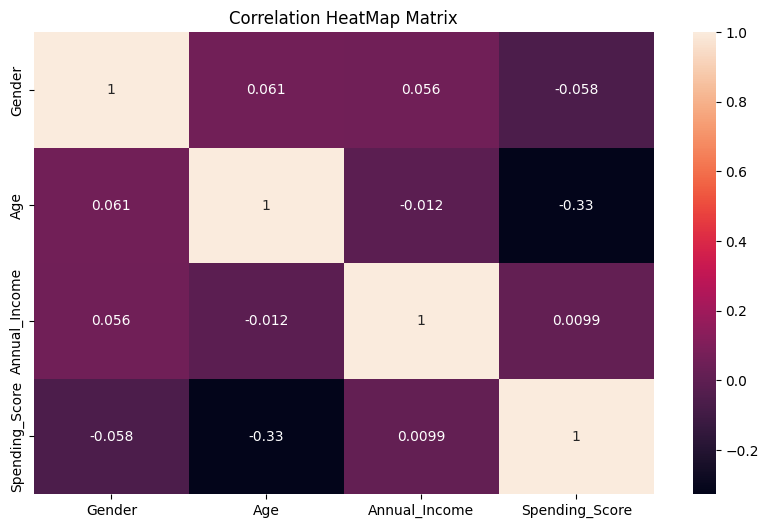

In [835]:
#### To get the graphical representation for the correlation for all the numerical columns in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graphical representation depicts about the numerical correlation for all the column used in the dataset.

2.  The correlation between the 'Gender' and 'Age' is very high.

3.  The correlation between the 'Age' and 'Spending Score' is very low.

#### Step 6: Select Important Features

In [836]:
#### Select all the important features

X = df[['Annual_Income','Spending_Score']]

In [837]:
X

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


#### OBSERVATIONS:

1.  The features that were selected for performing the clustering operation in the dataset is 

    (a.)    Annual_Income

    (b.)    Spending_Score

#### Step 7: Perform the Feature Scaling on the selected features

In [838]:
from sklearn.preprocessing import StandardScaler

##### create an object for StandardScaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

In [839]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

#### OBSERVATIONS:

1.  Feature scaling standardizes all features to zero mean and unit variance.

2.  This prevents one feature from dominating due to larger scale.

#### Step 8: Estimate the bandwidth

In [840]:
bandwidth = estimate_bandwidth(
    X_scaled                                            ,
    quantile            =           0.2                 ,
    n_samples           =           len(X_scaled)
)

In [841]:
bandwidth

np.float64(1.046673351189705)

#### Step 9: Train the Mean Shift Clustering

In [842]:
from sklearn.cluster import MeanShift

#### create an object for MeanShift

ms = MeanShift(
    bandwidth   =   bandwidth
)


#### Train the Mean shift model with the input data
ms.fit(X_scaled)

MeanShift(bandwidth=np.float64(1.046673351189705))

#### Step 10: Predict the Cluster Labels

In [843]:
Y_pred = ms.labels_

In [844]:
Y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

#### OBSERVATIONS:

1.  We have predicted the cluster labels for the given input scaled data.

#### Step 11: Add the cluster labels to the dataset

In [845]:
df['Labels'] = Y_pred

In [846]:
df.head()

,Gender,Age,Annual_Income,Spending_Score,Labels
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,0
3,0,23,16,77,0
4,0,31,17,40,0


#### OBSERVATIONS:

1.  All the cluster labels have been added to the dataset.

#### Step 12: Find the Number of Clusters

In [847]:
n_clusters = len(np.unique(Y_pred))

print("Number of clusters formed is:", n_clusters)

Number of clusters formed is: 3


#### Step 13: Find the cluster centers

In [848]:
cluster_centers = ms.cluster_centers_

print("Cluster Centers are :", cluster_centers)

Cluster Centers are : [[-0.21397694 -0.05684904]
 [ 0.75060182  1.12291364]
 [ 0.77516084 -1.12541661]]


#### OBSERVATIONS:

1.  kmeans.cluster_centers_ =============>  obtains the centroid values for all the custers.

2.  But the centroid values are all in the scaled form.

3.  We need to convert the scaled form of the centroids to the original form.

In [849]:
original_centroids = sc.inverse_transform(cluster_centers)

In [850]:
original_centroids

array([[54.95402299, 48.73563218],
       [80.225     , 79.125     ],
       [80.86842105, 21.21052632]])

#### OBSERVATIONS:

1.  Here by using inverse_transform , we have obtained the original form of all the scaled values of the centroid.

#### Step 14: Visualize the clusters

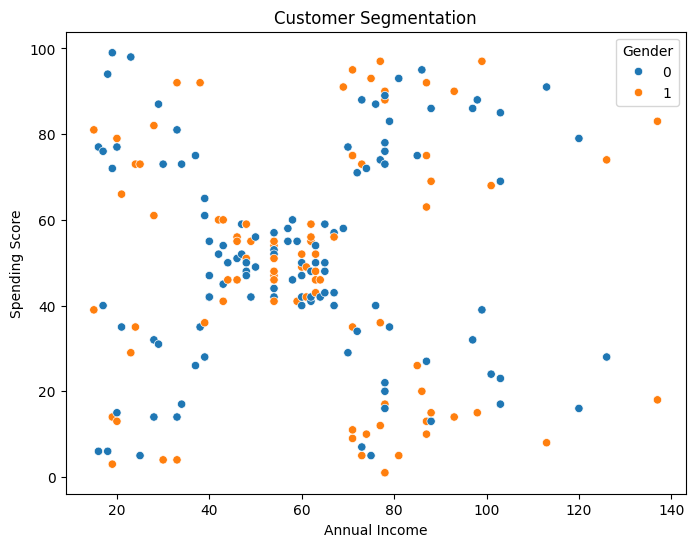

In [851]:
#### (a.) Visualize the Clusters

plt.figure(figsize=(8,6))

#### perform the scatterplot
sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'],hue=df['Gender'])

#### Give the title of the graph
plt.title("Customer Segmentation")

#### Give the x label for the graph
plt.xlabel("Annual Income")

#### Give the y label for the graph
plt.ylabel("Spending Score")

#### Display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the Customer Segmentation of Annual Income vs Spending Score for various Male and Feamle Customers.

2.  The above graph also explains about

        (a.)    Customers with high Annual income + high spending score

        (b.)    Customers with high Annual income + less spending score

        (c.)    Customers with low  Annual income + high spending score

        (d.)    Customers with low  Annual income + less spending score

3. In general, this graph explains about the female customers spend more than the male customers.

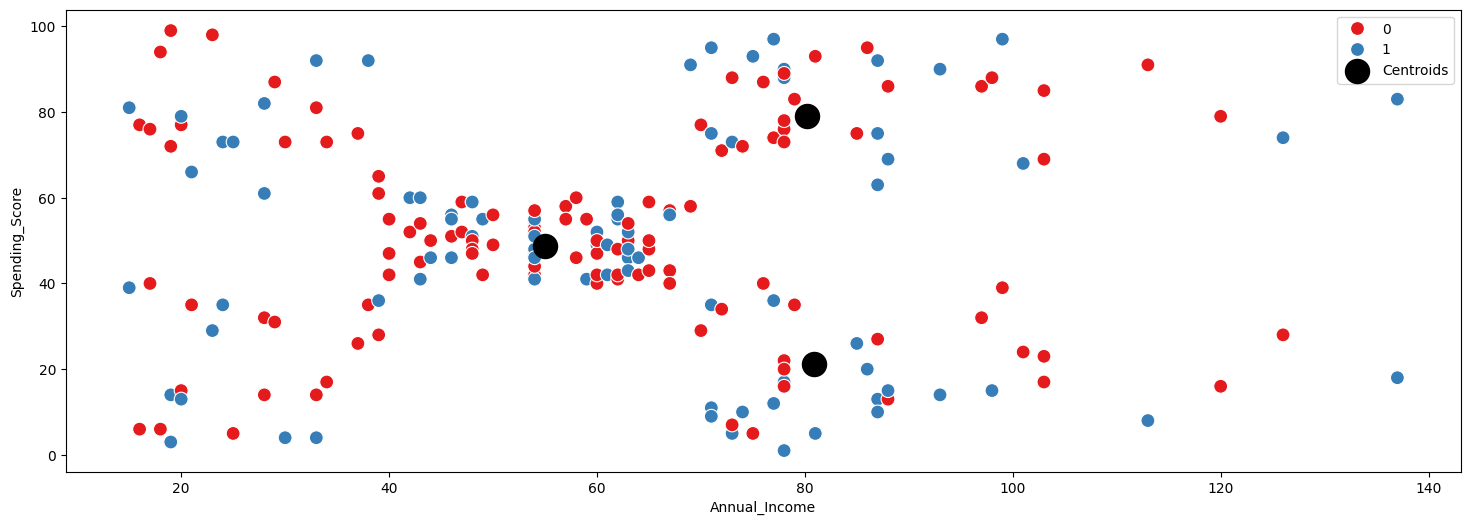

In [852]:
#### (a.) Visualize the Clusters with centroids

plt.figure(figsize=(18,6))

#### Plot the original data
sns.scatterplot(x=df['Annual_Income'],y=df['Spending_Score'], hue=df['Gender'],palette='Set1',s=100)

#### PLot the centroids
plt.scatter(
    original_centroids[:,0]                                                         ,
    original_centroids[:,1]                                                         ,
    s               =                       300                                     ,
    c               =                      'black'                                  ,
    marker          =                       'o'                                     ,
    label           =                      'Centroids'                              
)

### Plot the legends

plt.legend()

#### Display the graph
plt.show()

#### OBSERVATIONS:

1.  The above dataset explains about the customer details for the Annual_Income vs Spending_Score.

2.  There are a total of five clusters formed in the dataset.

3.  For each and every cluster, centroids are formed for each and every cluster.

4.  The spending score of the female customers is much higher than the male customers.

#### Step 15:  Evaluate the Quality of Clustering

In [853]:
from sklearn.metrics    import silhouette_score

score = silhouette_score(X_scaled, Y_pred)

print("Silhouette score of the cluster is:", score)

Silhouette score of the cluster is: 0.4613230919551735


#### OBSERVATIONS:

1.  Here the Silhouette Score of the cluster is 0.46. 

2.  The Silhouette Scoring of the cluster is 0.46 which is an average clustering quality
 

#### Silhouette Scoring Interpretation:-------

 | Score       | Meaning              |
 | ----------- | -------------------- |
 | < 0.25      | Poor clustering      |
 | 0.25 – 0.50 | Average clustering   |
 | 0.50 – 0.70 | Good clustering      |
 | > 0.70      | Excellent clustering |